# 01 &mdash; Rolling-Window Backtest on Raw Prices

This notebook is the starting point of the benchmark. The numbered
list below is both the table of contents for what you're about to
run *and* the order in which we actually worked through the
problem &mdash; the section headings inside the notebook match it.

1. **Source the data.** Download the ICE *Coffee C* report as an
   `.xls` from [ice.com/report/293](https://www.ice.com/report/293)
   (downloaded February 2026), pick a single column to forecast
   &mdash; the *nearby close* &mdash; and save the trimmed result
   as `data/coffee.csv` for the rest of the project to import. We
   work with one column throughout this project.
2. **Assemble a 10-model suite.** Five categories &mdash; simple
   baselines, classical statistical, volatility, structural, and
   foundation models &mdash; selected to span a range of approaches
   and complexity.
3. **First test: a single forecast.** Hold out the most recent 63
   trading days and let every model forecast them from the prior
   1,536-day context. This was the real starting point of the
   benchmark &mdash; the first plot of forecasts against realized
   prices and the first error table. Granite TTM won this run,
   which lined up with our going-in expectation that the more
   sophisticated models would dominate. The
   multi-origin results in §6 turn out differently.
4. **Forecast-origin coverage.** One window isn't enough to draw
   a conclusion &mdash; that much was clear from the start &mdash;
   so we wanted multiple origins distributed across the 32-year
   history. The 1, 10, 30, 60 sequence is the trail of that
   decision: 10 looked too sparse on the coverage plot, 30 was
   better, 60 covered the series without origins crowding into
   each other.
5. **Run the rolling-window backtest at every scale.** We ran the
   suite scale by scale (10, then 30, then 60), checking results
   at each step rather than firing the whole thing at once. The
   iterative approach was simply more careful, and storing every
   intermediate output paid off later &mdash; how MAE rankings
   stabilize as scale grows becomes its own visualization in §9.
6. **Export the two CSVs** every downstream notebook consumes.
7. **Per-model visualizations.** Four views of the benchmark
   output: how MAE rankings stabilize across scales (§9), the
   zoomed leaderboard at scale=60 (§10), per-model MAE distributions
   across the 60 origins (§11), and a per-origin Granite TTM vs.
   RWD comparison (§12).

| File | Rows | Purpose |
|---|---|---|
| `results/csv/summary_all_scales.csv` | `101 x 10 = 1,010` | One row per (origin, model); MAE / RMSE / MAPE / sMAPE / MASE |
| `results/csv/step_errors_all_scales.csv` | `101 x 10 x 63 = 63,630` | One row per (scale, model, origin, step); absolute error at each forecast step |

The step-errors table is the input to the Diebold-Mariano test and the Model
Confidence Set in notebook 02.

## Backtest design

- **Context window:** 1,536 trading days ($\approx$ 6 years). Granite
  TTM offers several zero-shot context-length variants
  (512, 1024, 1536); we picked the largest to give every model as
  much history as possible while keeping the comparison fair across
  the suite.
- **Horizon:** 63 trading days ($\approx$ 3 months), a middle ground
  between a horizon too short to be interesting and one too long to
  be defensible.
- **Scales:** 1, 10, 30, 60 evenly-spaced forecast origins. 60 is the
  one we settled on; the rest are the trial-and-error that got
  us there.
- No model sees test data during fitting; every origin gets a fresh
  fit on the preceding 1,536 days.


## 1. Environment setup

In [32]:
import logging
import random
import sys
from pathlib import Path

# Make `coffee_forecast` importable whether or not `pip install -e .`
# is in effect for this kernel. No-op when the package is already on
# sys.path (e.g. via the editable install); falls back to inserting
# the repo root so the notebook also runs from a fresh clone.
try:
    import coffee_forecast  # noqa: F401
except ModuleNotFoundError:
    sys.path.insert(0, str(Path.cwd().parent))

# Mute the noisiest third-party libraries.
for name in ("cmdstanpy", "prophet", "statsforecast"):
    logging.getLogger(name).setLevel(logging.ERROR)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch

from coffee_forecast import (
    load_coffee_data,
    run_multi_scale_backtest,
    StatsForecastWrapper,
    GARCHWrapper,
    ProphetWrapper,
    MLRecursiveWrapper,
    GraniteWrapper,
)
from coffee_forecast.backtest import step_errors_to_long_df
from coffee_forecast.config import (
    CONTEXT_LEN,
    HORIZON,
    SCALES,
    SEED,
    CSV_DIR,
    FIG_DIR,
    REPO_ROOT,
)
from coffee_forecast.viz import plot_price_series, plot_forecast_origin_coverage

# Seed every stochastic component we touch directly. Most of the suite
# (statsforecast MLE, arch MLE, Granite TTM, Prophet MAP) is deterministic
# given fixed inputs; RandomForest takes ``random_state=SEED`` at
# construction (see §3). Setting these global seeds guards against any
# incidental randomness in feature construction or library internals.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Ensure output directories exist.
CSV_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)


## 2. From .xls to a tidy .csv

The raw `.xls` from
[ice.com/report/293](https://www.ice.com/report/293) is a single
sheet with 43 columns &mdash; the nearby contract plus four
later-dated expiries, each carrying `CONTRACT (YYYY/MM)`, `HIGH`,
`LOW`, `CLOSE`, `OPEN INTEREST`, `VOLUME`, with a couple of
volatility series tacked on at the end &mdash; and four header rows
above the data. The only column we use is the **nearby close**, so
the one-time script below strips the file down to two columns and
saves the result as `data/coffee.csv`. After that, every notebook
and script imports the .csv directly.

The script is [scripts/export_csv.py](../scripts/export_csv.py):

```python
df = pd.read_excel("data/Coffee_Historical_Prices.xls", engine="xlrd")
df = df.iloc[4:, [0, 9]]                          # skip header rows; keep DATE + nearby CLOSE
df = df.rename(columns={df.columns[0]: "ds", df.columns[1]: "y"})
df["ds"] = pd.to_datetime(df["ds"])
df["y"]  = pd.to_numeric(df["y"])
df = df.dropna(subset=["y"]).reset_index(drop=True)
df.to_csv("data/coffee.csv", index=False)
```

`load_coffee_data` in `coffee_forecast/data.py` is the thin reader
the notebook calls: it loads the .csv, parses the date column,
normalizes timestamps to midnight, sorts by date, and adds the
`unique_id` column `statsforecast` requires.


In [33]:
df = load_coffee_data()
print(
    f"Loaded {len(df)} trading days ({df['ds'].min().date()} → {df['ds'].max().date()})"
)
df.head()

Loaded 8104 trading days (1994-01-03 → 2026-01-30)


,ds,y,unique_id
0,1994-01-03,72.50,coffee
1,1994-01-04,71.85,coffee
2,1994-01-05,71.55,coffee
3,1994-01-06,72.10,coffee
4,1994-01-07,72.50,coffee


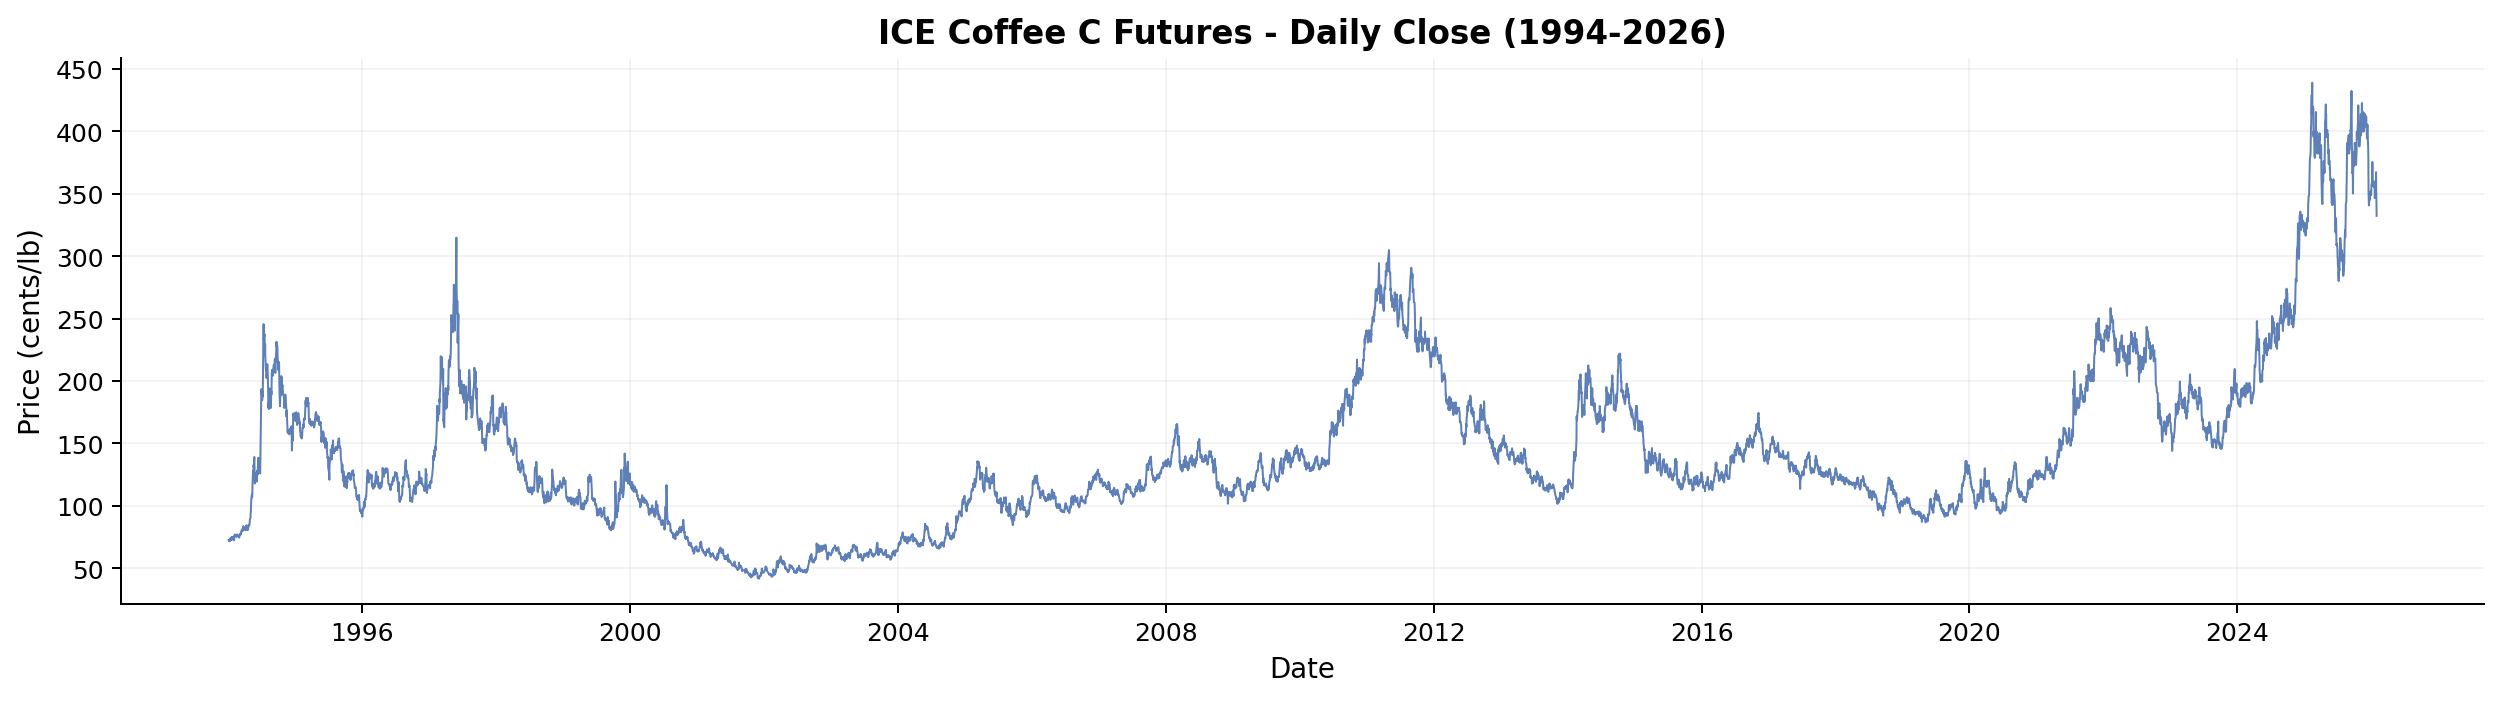

In [34]:
_ = plot_price_series(df, save_path=FIG_DIR / "price_series.png")
plt.show()

## 3. Assemble the 10-model suite

Every wrapper exposes a uniform `predict(context_df, horizon) -> ndarray`
interface, so the backtest runner treats them all identically.

| Category | Models |
|---|---|
| Simple baselines | Naive, RWD (random walk with drift), Theta |
| Classical statistical | ETS (AutoETS), ARIMA (AutoARIMA) |
| Volatility | GARCH(1,1) with AR(1) mean |
| Structural decomposition | Prophet |
| Recursive ML | Ridge, Random Forest (lag + rolling features) |
| Foundation (zero-shot) | IBM Granite TTM |

> **GARCH note.** This is the simple GARCH(1,1)-Normal spec on raw
> prices, used here for its point forecast. Notebook 05 deploys a
> richer GJR-GARCH(1,1)-t spec on log-returns; that variant lives
> there because deployment is about prediction intervals, where the
> volatility specification does the work, not point forecasts.


In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from statsforecast.models import (
    AutoARIMA,
    AutoETS,
    Naive,
    RandomWalkWithDrift,
    Theta,
)
from tsfm_public.toolkit.get_model import get_model

device = "cuda" if torch.cuda.is_available() else "cpu"

ttm = (
    get_model(
        model_path="ibm-granite/granite-timeseries-ttm-r2",
        model_name="ttm",
        context_length=CONTEXT_LEN,
        prediction_length=96,  # fixed by this Granite TTM variant; trimmed to HORIZON in GraniteWrapper
        prefer_longer_context=True,
        return_model_key=False,
    )
    .to(device)
    .eval()
)
print(f"IBM Granite TTM loaded on {device.upper()}")

models = {
    # Simple baselines
    "Naive": StatsForecastWrapper(Naive(alias="Naive")),
    "RWD": StatsForecastWrapper(RandomWalkWithDrift(alias="RWD")),
    "Theta": StatsForecastWrapper(Theta(season_length=252, alias="Theta")),
    # Classical
    "ETS": StatsForecastWrapper(AutoETS(alias="ETS")),
    "ARIMA": StatsForecastWrapper(AutoARIMA(seasonal=False, alias="ARIMA")),
    # Volatility
    "GARCH": GARCHWrapper(),
    # Structural decomposition
    "Prophet": ProphetWrapper(),
    # Recursive ML
    "Ridge": MLRecursiveWrapper(make_pipeline(StandardScaler(), Ridge())),
    "RF": MLRecursiveWrapper(
        RandomForestRegressor(n_estimators=100, random_state=SEED)
    ),
    # Foundation model
    "Granite-TTM": GraniteWrapper(ttm, device, context_len=CONTEXT_LEN),
}
print(f"{len(models)} models initialized across 5 categories.")


INFO:p-14134:t-8478283968:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-14134:t-8478283968:get_model.py:get_model:Model path type is 2
INFO:p-14134:t-8478283968:get_model.py:get_model:Attempting model load from ibm-granite/granite-timeseries-ttm-r2, revision = 1536-96-r2.
INFO:p-14134:t-8478283968:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = 1536-96-r2.
INFO:p-14134:t-8478283968:get_model.py:get_model:[TTM] context_length = 1536, prediction_length = 96


IBM Granite TTM loaded on CPU
10 models initialized across 5 categories.


## 4. First test: a single forecast

We started by forecasting straight into the future. The outputs
looked reasonable, but without realized prices to compare against
we couldn't compute any error metrics. So we pulled the test
window back to the most recent 63 trading days, where real prices
already existed. Each model saw the 1,536 days before that as
context and predicted the 63 days we already knew. A natural first
choice of window, but enough to see real forecasts plotted against
real prices for the first time. The metrics from this single
window are saved as `single_origin_metrics.csv`.


In [36]:
from coffee_forecast import calculate_metrics, get_forecast_origins
from coffee_forecast.config import COLOR_MAP, PLOT_ORDER

# Same machinery as the rolling-window backtest at scale=1: the latest
# valid forecast origin in the series.
a = get_forecast_origins(df, num_windows=1)[0]
context_df = df.iloc[a - CONTEXT_LEN : a].copy()
test_df = df.iloc[a : a + HORIZON].copy()
y_true = test_df["y"].to_numpy(dtype=float)
train_y = context_df["y"].to_numpy(dtype=float)
test_start = test_df["ds"].iloc[0]

# Generate forecasts.
plot_df = pd.DataFrame({"ds": test_df["ds"].to_numpy(), "Actual": y_true})
for name, wrapper in models.items():
    plot_df[name] = wrapper.predict(context_df, HORIZON)
    print(f"  ✓ {name}")

# Single-origin metrics, sorted by MAE.
rows = []
for name in PLOT_ORDER:
    y_hat = plot_df[name].to_numpy(dtype=float)
    metrics = calculate_metrics(y_true, y_hat, train_y)
    metrics["Model"] = name
    rows.append(metrics)

holdout_metrics = (
    pd.DataFrame(rows)
    .sort_values("MAE")
    .reset_index(drop=True)[["Model", "MAE", "RMSE", "sMAPE", "MASE"]]
)
holdout_metrics.to_csv(CSV_DIR / "single_origin_metrics.csv", index=False)
print("\nSaved: results/csv/single_origin_metrics.csv")
holdout_metrics.round(3)


  ✓ Naive
  ✓ RWD
  ✓ Theta
  ✓ ETS
  ✓ ARIMA
  ✓ GARCH
  ✓ Prophet
  ✓ Ridge
  ✓ RF
  ✓ Granite-TTM

Saved: results/csv/single_origin_metrics.csv


,Model,MAE,RMSE,sMAPE,MASE
0,Granite-TTM,20.875,22.601,0.055,5.781
1,GARCH,23.348,25.852,0.062,6.466
2,RF,24.552,26.087,0.065,6.800
3,Ridge,24.709,29.209,0.065,6.843
4,ETS,26.039,29.876,0.069,7.212
5,Naive,26.039,29.876,0.069,7.212
6,ARIMA,26.044,29.927,0.069,7.213
7,Theta,27.325,31.971,0.072,7.568
8,RWD,29.231,35.043,0.077,8.096
9,Prophet,49.243,60.306,0.124,13.638


Granite TTM tops the leaderboard on this single window, which made
us optimistic moving forward. The multi-origin backtest in §6 turns
the story upside down: RWD, second-to-last on this single window,
ends up the mean-MAE leader across 60 origins.


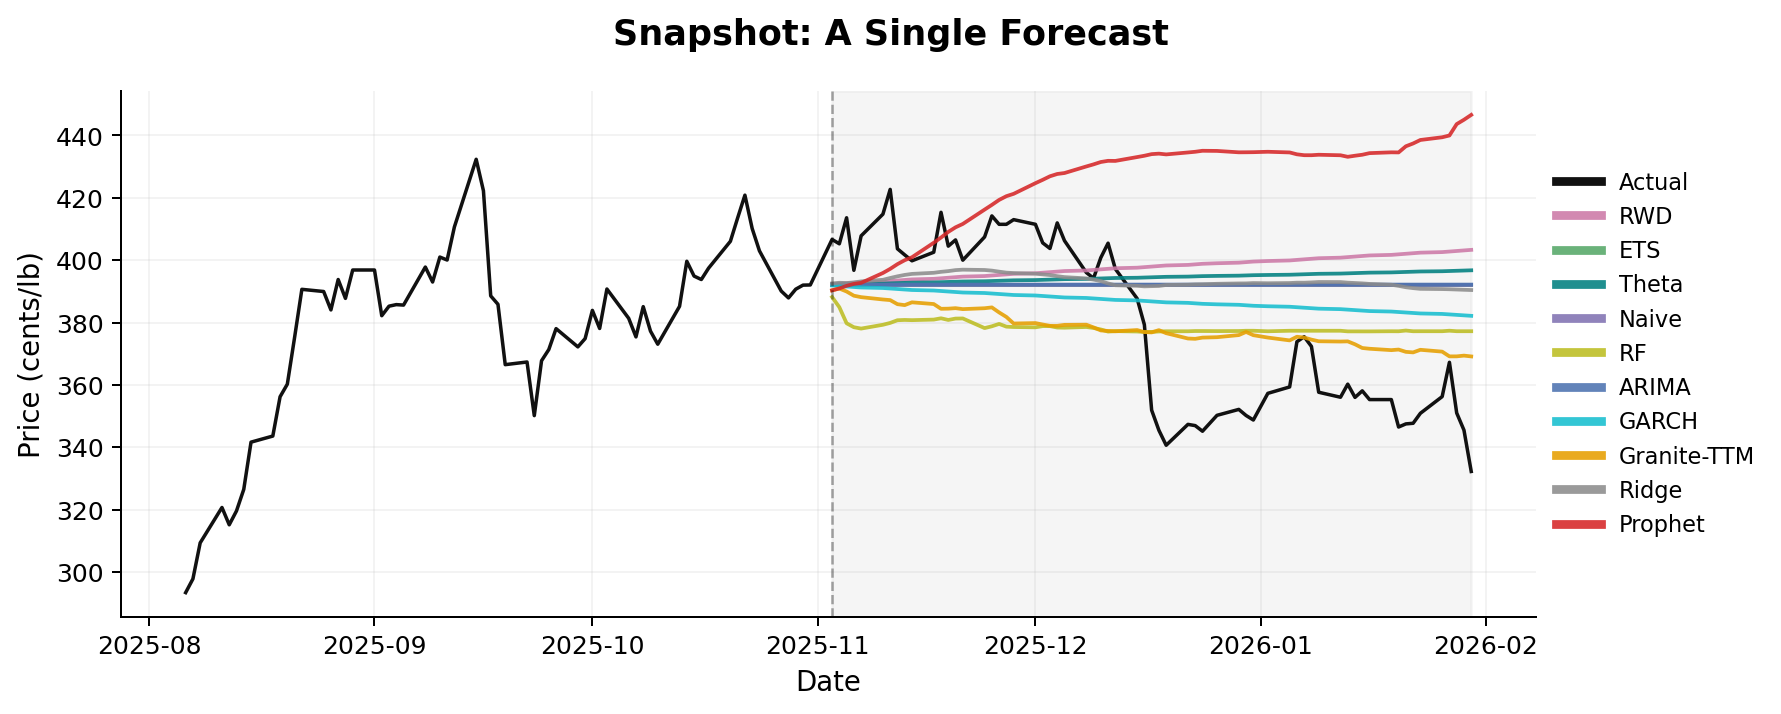

In [37]:
# Show the last 63 trading days *before* the holdout for context
VIS_DAYS = HORIZON
vis_start = max(0, a - VIS_DAYS)
vis_df = df.iloc[vis_start : a + HORIZON][["ds", "y"]].copy()

fig, ax = plt.subplots(figsize=(10, 4), dpi=180)

ax.axvspan(test_start, vis_df["ds"].max(), color="gray", alpha=0.08)
ax.plot(
    vis_df["ds"], vis_df["y"], color=COLOR_MAP["Actual"], linewidth=1.4, label="Actual"
)

for name in PLOT_ORDER:
    if name not in plot_df.columns:
        continue
    y_hat = plot_df[name].to_numpy(dtype=float)
    if np.any(~np.isfinite(y_hat)):
        continue
    ax.plot(
        plot_df["ds"],
        y_hat,
        color=COLOR_MAP.get(name, "#666666"),
        linewidth=1.5,
        alpha=0.88,
        label=name,
    )

ax.axvline(test_start, ls="--", linewidth=1, color="black", alpha=0.35)

fig.suptitle("Snapshot: A Single Forecast", fontsize=14, weight="semibold", y=0.98)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Price (cents/lb)", fontsize=11)
ax.grid(True, alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

leg = ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=9)
for line in leg.get_lines():
    line.set_linewidth(3.5)

fig.tight_layout()
fig.savefig(FIG_DIR / "coffee_holdout_plot.png", dpi=300, bbox_inches="tight")
plt.show()


**Reading this plot.** Each model's 63-day forecast, overlaid with
the realized path. Visually, everything looks sensible: the simple
baselines cluster near the last observation, and the more flexible
models (Prophet, Granite-TTM) make stronger directional claims.
Granite-TTM in particular tracks the realized path more closely than
anything else, which set our expectations going into the broader test.


## 5. Forecast origin coverage

With the single-window check behind us, we needed multiple origins
to fairly cover the 32-year series. We started at 10 because it felt
reasonable, but on second look the origins were too sparse to
represent the full range of regimes in the data. We bumped it to 30
(better), then 60, close enough together to feel robust without
crowding or overlapping. The plot below shows where each set of
origins falls on the price history.


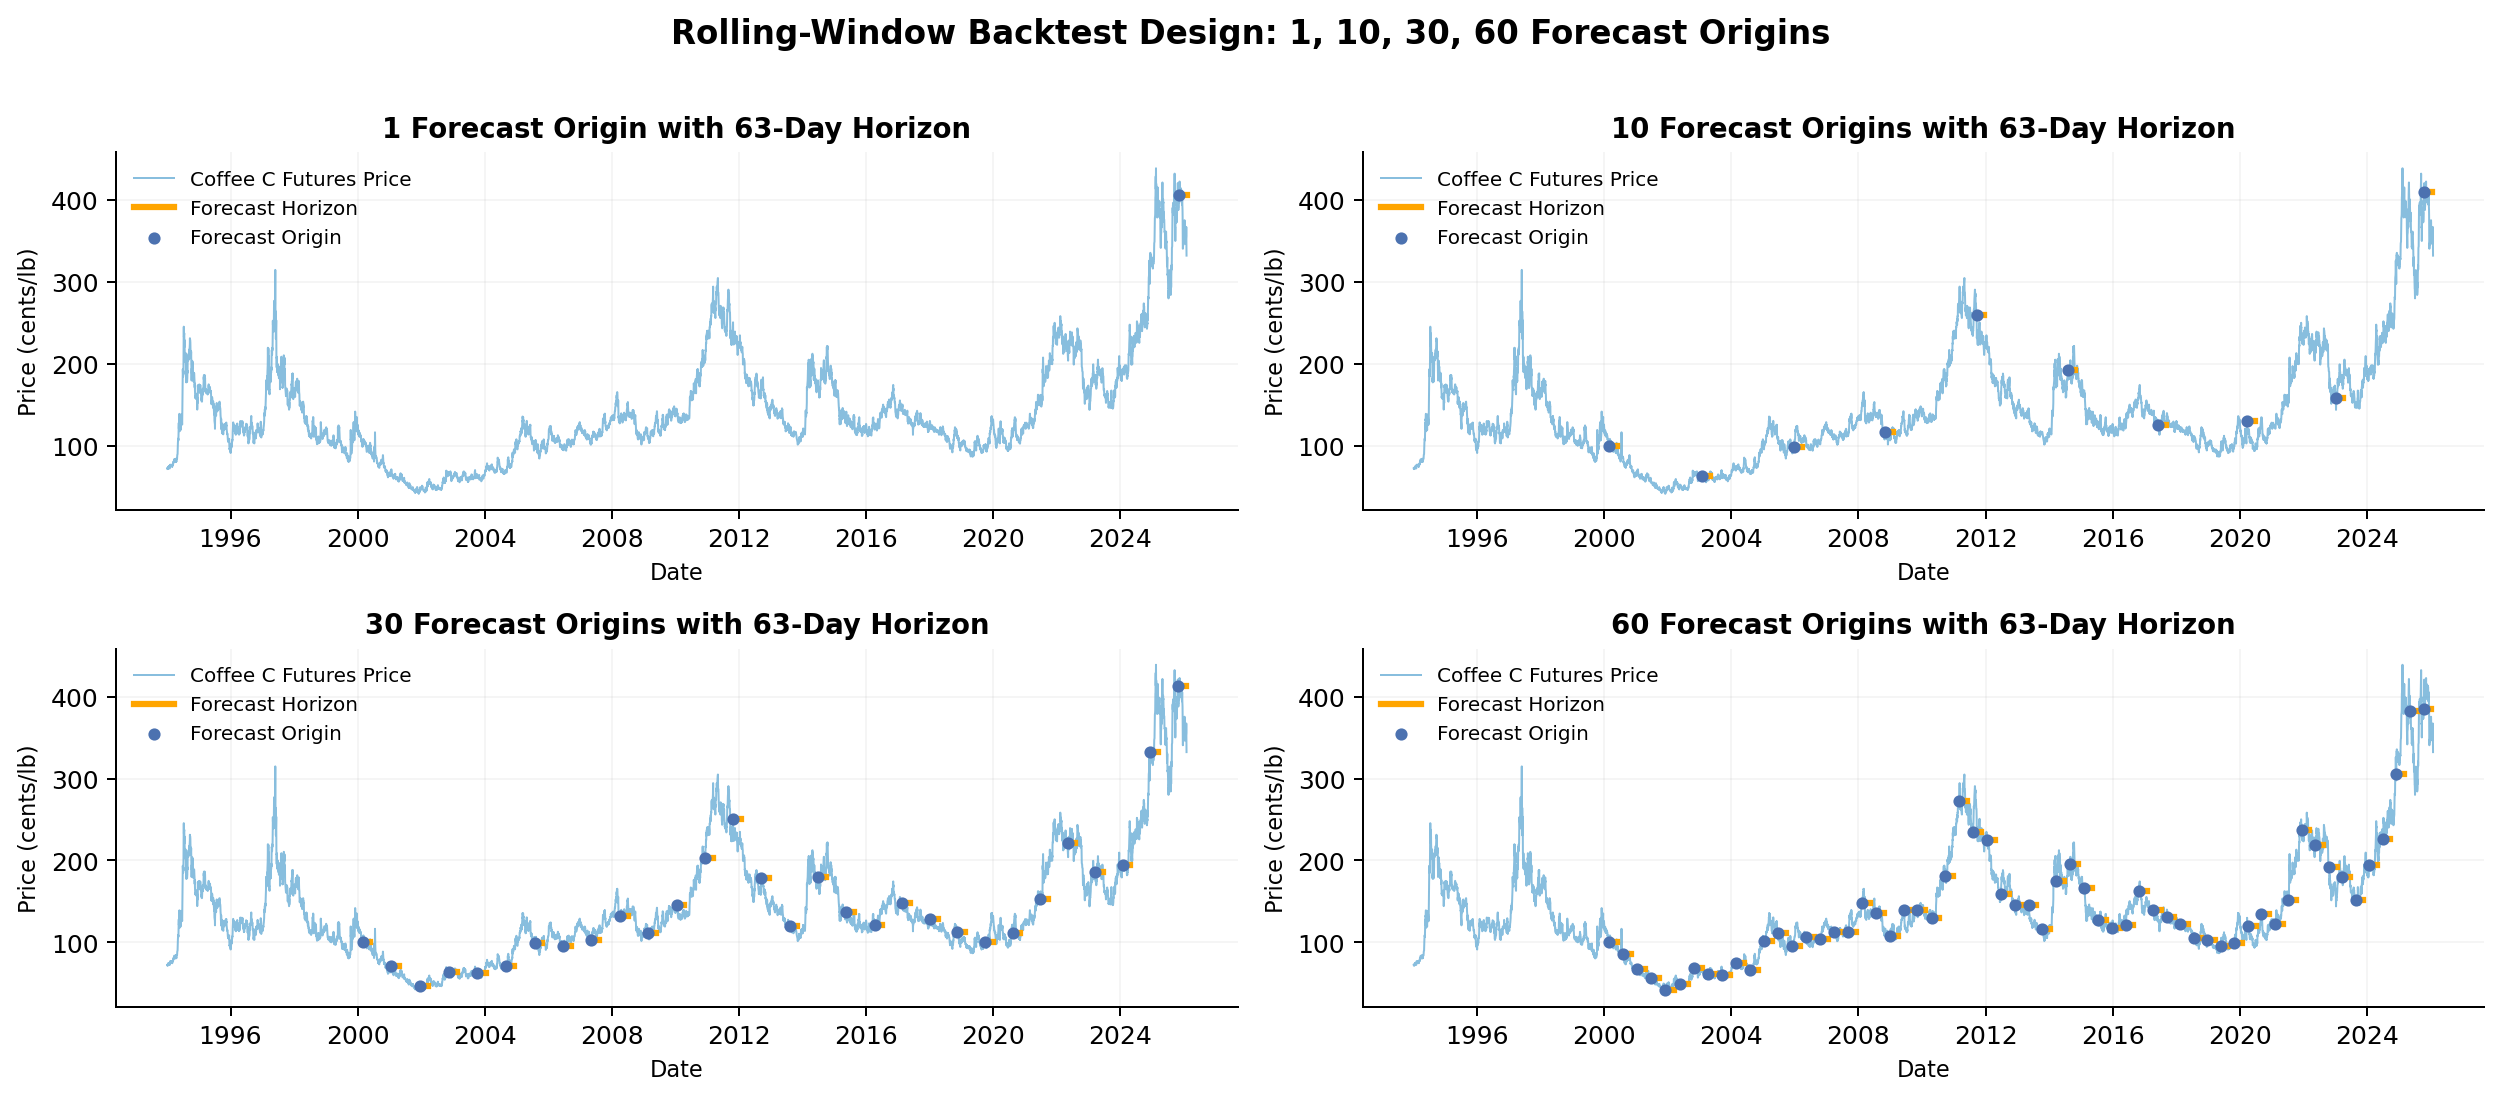

In [38]:
_ = plot_forecast_origin_coverage(
    df,
    scales=SCALES,
    save_path=FIG_DIR / "forecast_origin_coverage.png",
)
plt.show()

## 6. Run the rolling-window backtest

In practice we ran the rolling backtest scale by scale (10, then
30, then 60) as we iterated on the design. The cell below collapses
that into one sequential run for reproducibility &mdash; it
includes scale=1, which reproduces the §4 single-origin test.

`run_multi_scale_backtest` loops every (scale, model) combination and returns:

- `summary`: long-format DataFrame with one row per (origin, model, scale).
- `step_errors`: nested dict where `step_errors[scale][model_name]` is
  an ndarray of shape `(num_origins, horizon)` with absolute errors at
  each step. This per-step table is what feeds the Diebold-Mariano test
  in notebook 02.


In [39]:
summary, step_errors = run_multi_scale_backtest(
    df=df,
    models=models,
    scales=SCALES,
    context_len=CONTEXT_LEN,
    horizon=HORIZON,
    verbose=True,
)
print(f"\nTotal rows in summary: {len(summary)}")
summary.head()


Running 1 forecast origin(s)...
  ✓ Naive
  ✓ RWD
  ✓ Theta
  ✓ ETS
  ✓ ARIMA
  ✓ GARCH
  ✓ Prophet
  ✓ Ridge
  ✓ RF
  ✓ Granite-TTM

Running 10 forecast origin(s)...
  ✓ Naive
  ✓ RWD
  ✓ Theta
  ✓ ETS
  ✓ ARIMA
  ✓ GARCH
  ✓ Prophet
  ✓ Ridge
  ✓ RF
  ✓ Granite-TTM

Running 30 forecast origin(s)...
  ✓ Naive
  ✓ RWD
  ✓ Theta
  ✓ ETS
  ✓ ARIMA
  ✓ GARCH
  ✓ Prophet
  ✓ Ridge
  ✓ RF
  ✓ Granite-TTM

Running 60 forecast origin(s)...
  ✓ Naive
  ✓ RWD
  ✓ Theta
  ✓ ETS
  ✓ ARIMA
  ✓ GARCH
  ✓ Prophet
  ✓ Ridge
  ✓ RF
  ✓ Granite-TTM

Total rows in summary: 1010


,MAE,RMSE,MAPE,sMAPE,MASE,origin_id,origin_date,model,scale
0,26.038889,29.875577,0.071331,0.068703,7.211687,1,2025-11-03,Naive,1
1,29.230761,35.042854,0.080769,0.076698,8.095703,1,2025-11-03,RWD,1
2,27.325129,31.970789,0.075154,0.071951,7.567922,1,2025-11-03,Theta,1
3,26.038889,29.875575,0.071331,0.068703,7.211687,1,2025-11-03,ETS,1
4,26.044184,29.926982,0.071368,0.068716,7.213154,1,2025-11-03,ARIMA,1


## 7. Export CSVs for downstream notebooks

Both files are stored in `results/csv/`. Notebook 02 (backtest stats)
reads them directly and does not need to re-run the backtest. The
visualizations in §9&ndash;§12 below also use this same data, but
in-memory from the run we just completed.


In [40]:
summary_path = CSV_DIR / "summary_all_scales.csv"
summary.to_csv(summary_path, index=False)
print(f"Saved: {summary_path.relative_to(REPO_ROOT)}")

step_errors_df = step_errors_to_long_df(step_errors)
step_errors_path = CSV_DIR / "step_errors_all_scales.csv"
step_errors_df.to_csv(step_errors_path, index=False)
print(f"Saved: {step_errors_path.relative_to(REPO_ROOT)}  ({len(step_errors_df)} rows)")

Saved: results/csv/summary_all_scales.csv
Saved: results/csv/step_errors_all_scales.csv  (63630 rows)


## 8. The 60-origin leaderboard

The final ranking from the scale we settled on. The result was
genuinely surprising: RWD on top, Granite TTM mid-pack despite the
strong showing on the single window in §4. Whether these
differences are statistically meaningful, or whether the top of the
table is essentially a tie, is the question notebook 02 takes up
with the Diebold-Mariano test and the Model Confidence Set.


In [41]:
leaderboard = (
    summary[summary["scale"] == 60]
    .groupby("model")[["MAE", "RMSE", "MASE", "sMAPE"]]
    .mean()
    .sort_values("MAE")
)
print("60-origin mean metrics (sorted by MAE):")
leaderboard.round(3)

60-origin mean metrics (sorted by MAE):


,MAE,RMSE,MASE,sMAPE
model,,,,
RWD,12.789,14.841,6.103,0.083
ETS,12.819,14.893,6.110,0.085
Theta,12.862,14.934,6.133,0.085
Naive,12.909,14.986,6.147,0.085
RF,13.132,15.188,6.282,0.087
ARIMA,13.239,15.385,6.283,0.085
GARCH,13.505,15.740,6.504,0.090
Granite-TTM,13.842,16.089,6.551,0.092
Ridge,14.682,17.160,6.872,0.101


## 9. MAE stabilization across scales

Each model's mean MAE at scales 1, 10, 30, and 60. The question is
whether the ranking has *stabilized* by scale = 60. If it hasn't,
the statistical tests in notebook 02 would be on shaky ground. The
x-axis is plotted as four equally-spaced ordinal steps (rather than
to scale) so the early ramp from 1 to 10 doesn't get visually
compressed.


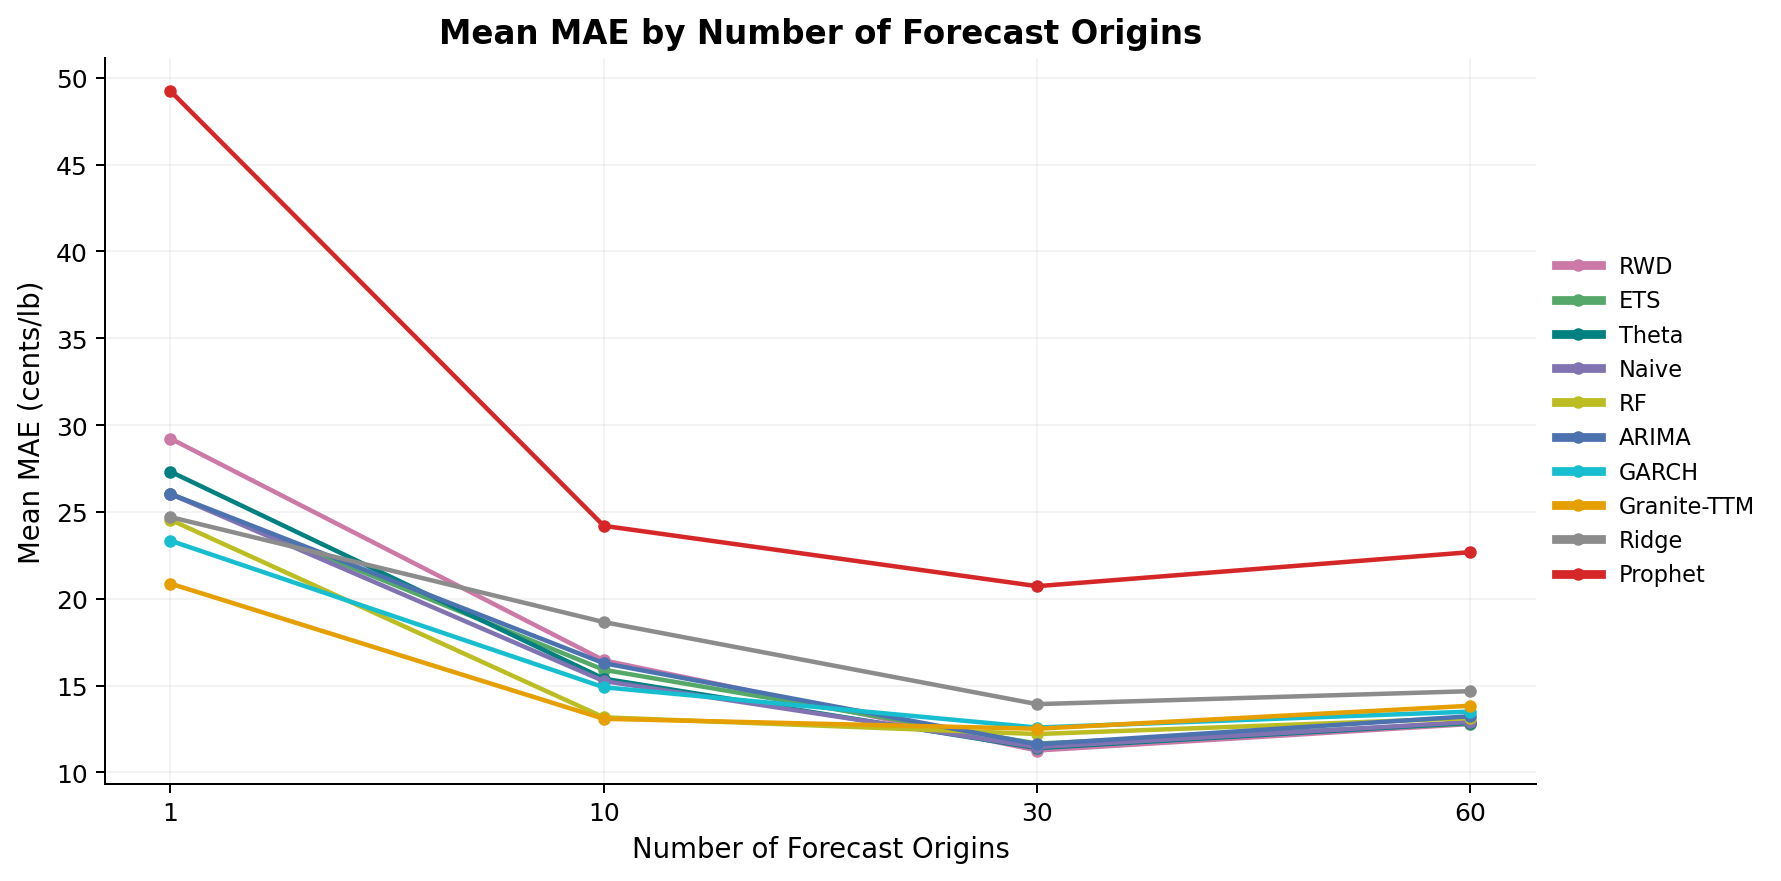

In [42]:
mae_by_scale = summary.groupby(["scale", "model"])["MAE"].mean().reset_index()

# Map true scales to equally spaced positions so 1 -> 10 -> 30 -> 60
# reads as four ordinal steps rather than a squashed linear axis.
scale_positions = {s: i for i, s in enumerate(SCALES)}

fig, ax = plt.subplots(figsize=(10, 5), dpi=180)
for name in PLOT_ORDER:
    model_data = mae_by_scale[mae_by_scale["model"] == name].sort_values("scale")
    x_pos = [scale_positions[s] for s in model_data["scale"]]
    ax.plot(
        x_pos,
        model_data["MAE"],
        marker="o",
        color=COLOR_MAP.get(name, "#666666"),
        linewidth=1.8,
        markersize=4,
        label=name,
    )

ax.set_title("Mean MAE by Number of Forecast Origins", fontsize=13, weight="semibold")
ax.set_xlabel("Number of Forecast Origins", fontsize=11)
ax.set_ylabel("Mean MAE (cents/lb)", fontsize=11)
ax.set_xticks(range(len(SCALES)))
ax.set_xticklabels(SCALES)
ax.grid(True, alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
leg = ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=9)
for line in leg.get_lines():
    line.set_linewidth(3.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "mae_stabilization.png", dpi=300, bbox_inches="tight")
plt.show()


**Reading this plot.** The nine non-Prophet models are nearly flat
from scale 30 to scale 60: the ranking has stabilized. Prophet sits
well above the cluster and is visibly noisier across scales. Sixty
origins is enough to resolve the remaining differences. The next
plot drops Prophet and zooms in on the 60-origin column so the
tight cluster of the other nine models is legible.


## 10. MAE at 60 origins, zoomed in

The nine non-Prophet models in isolation, sorted by mean MAE. This
is the same number as the rightmost column of the stabilization
plot above (scale = 60), rescaled so the differences are visible.


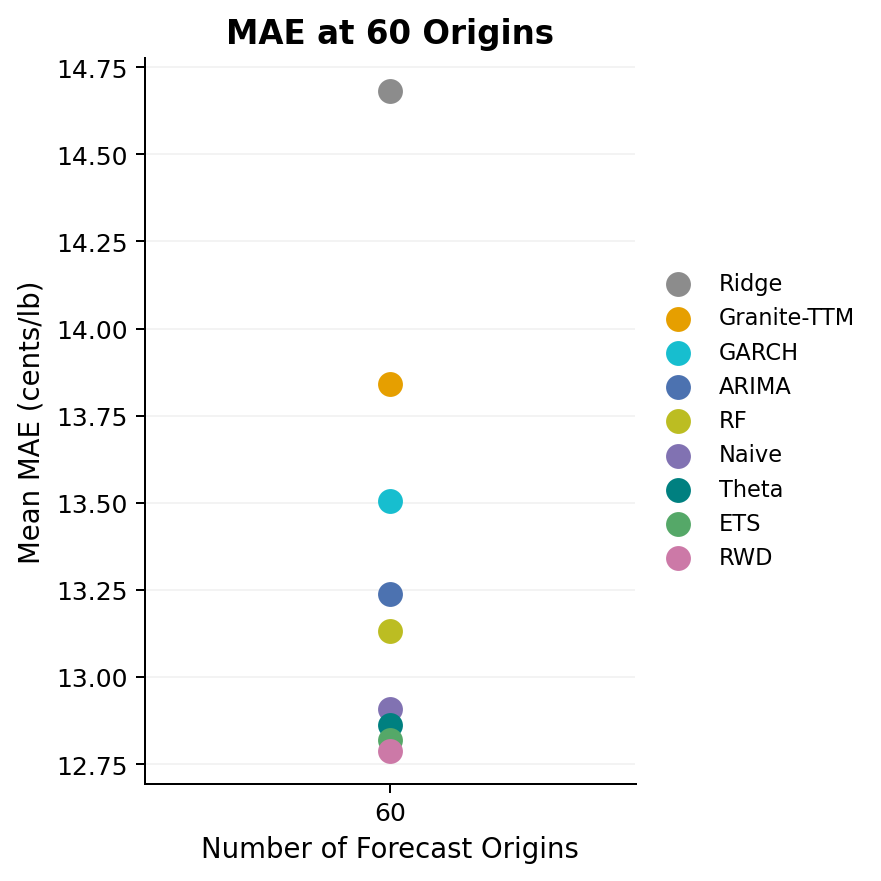

In [43]:
final = mae_by_scale[mae_by_scale["scale"] == 60].sort_values("MAE", ascending=False)
final = final[final["model"] != "Prophet"]  # Prophet off-scale; dropped for readability

fig, ax = plt.subplots(figsize=(5, 5), dpi=180)
for _, row in final.iterrows():
    ax.scatter(
        60,
        row["MAE"],
        color=COLOR_MAP.get(row["model"], "#666666"),
        s=80,
        zorder=3,
        label=row["model"],
    )

ax.set_ylabel("Mean MAE (cents/lb)", fontsize=11)
ax.set_xlabel("Number of Forecast Origins", fontsize=11)
ax.set_title("MAE at 60 Origins", fontsize=13, weight="semibold")
ax.set_xticks([60])
ax.set_xticklabels(["60"])
ax.set_xlim(55, 65)
ax.grid(True, alpha=0.15, axis="y")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False, fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "mae_final_60.png", dpi=300, bbox_inches="tight")
plt.show()


**Reading this plot.** At 60 origins the nine non-Prophet models
collapse into a vertical band only a few cents/lb wide. The simplest
models in the suite (RWD, Naive, Theta) cluster at the bottom of the
column with the lowest mean MAE; the more sophisticated approaches
(Granite-TTM, Ridge) sit above them. The visual spread is small
relative to the price level (~250 cents/lb on the recent window),
which is exactly the setup that motivates the Diebold-Mariano and
Model Confidence Set tests in the next notebook: the differences are
too small to eyeball.


## 11. MAE distribution at 60 origins

The mean MAE sorts the models, but it can hide fat tails: a model
that's average most of the time but occasionally explodes will look
worse than it deserves, and vice versa. Boxplots show the full
per-origin distribution: median, IQR, whiskers, and individual
origins that fell outside the whiskers.


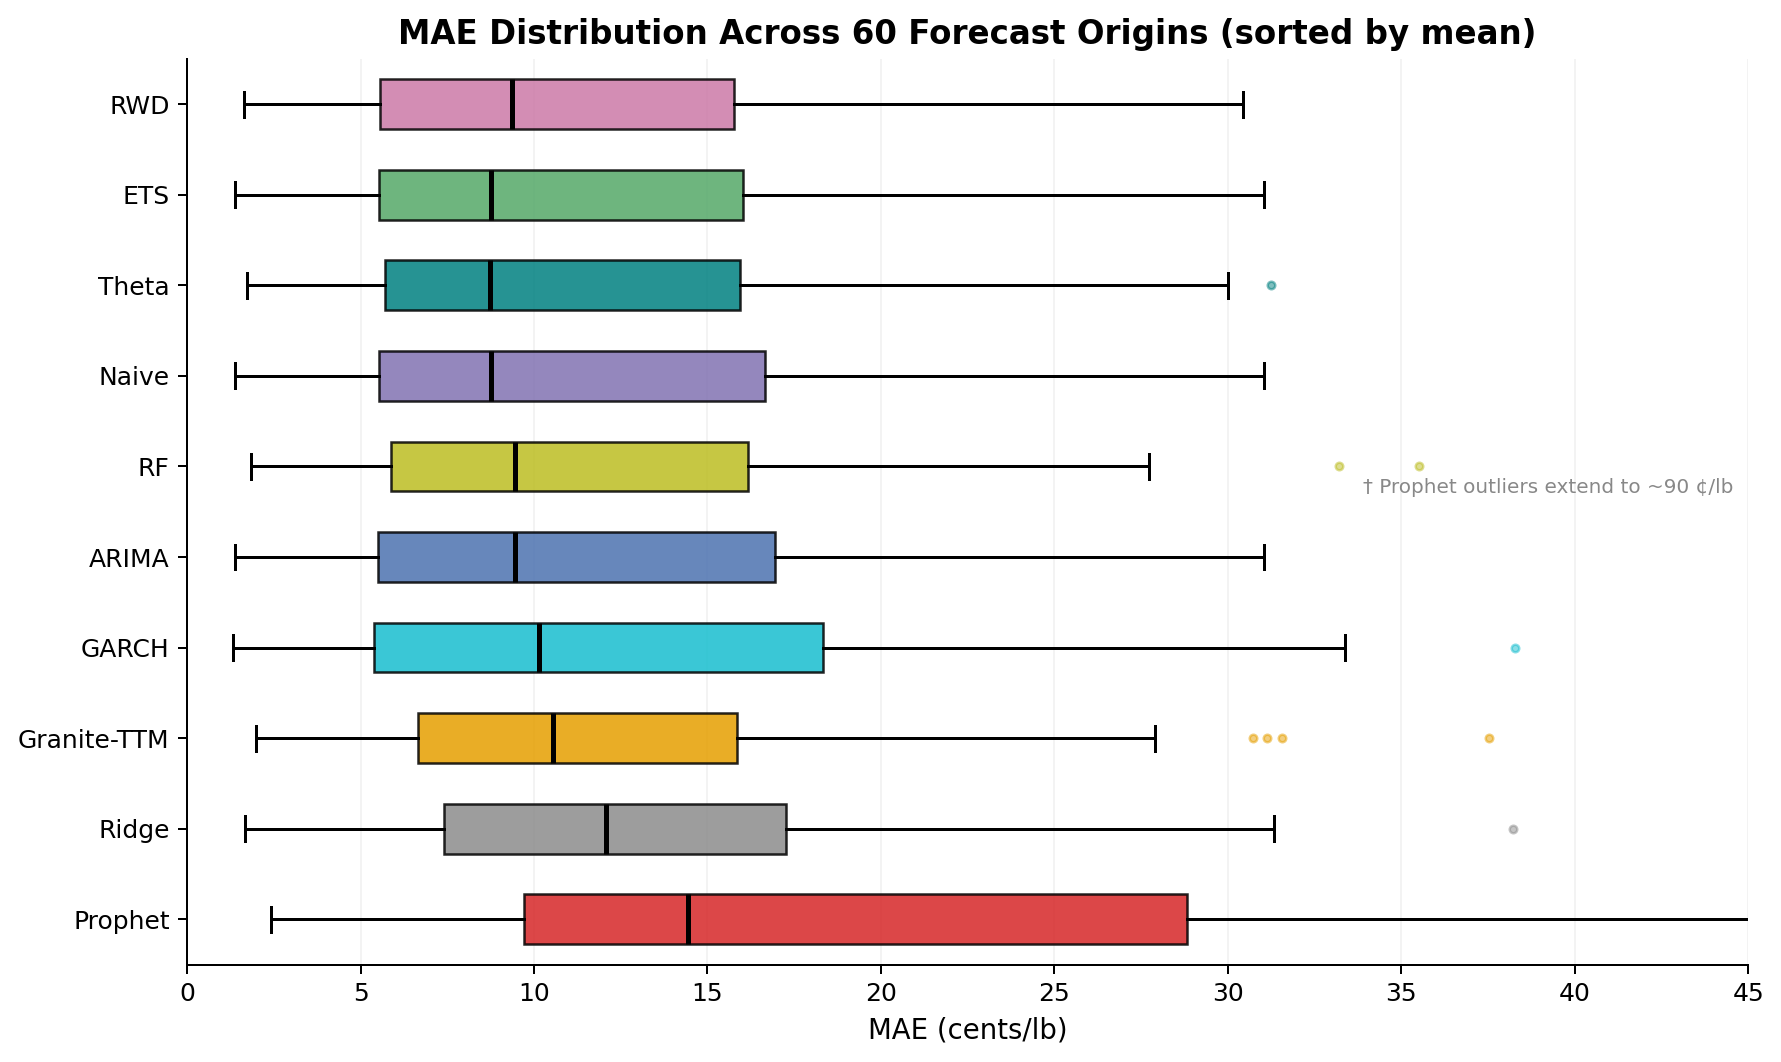

In [44]:
results_60 = summary[summary["scale"] == 60]
order = (
    results_60.groupby("model")["MAE"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)
data = [results_60[results_60["model"] == m]["MAE"].values for m in order]

fig, ax = plt.subplots(figsize=(10, 6), dpi=180)
bp = ax.boxplot(
    data,
    vert=False,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker="o", markersize=3, alpha=0.5),
    widths=0.55,
)
for patch, name in zip(bp["boxes"], order):
    patch.set_facecolor(COLOR_MAP.get(name, "#666666"))
    patch.set_alpha(0.85)
for flier, name in zip(bp["fliers"], order):
    flier.set_markerfacecolor(COLOR_MAP.get(name, "#666666"))
    flier.set_markeredgecolor(COLOR_MAP.get(name, "#666666"))

ax.set_xlim(0, 45)
ax.annotate(
    "† Prophet outliers extend to ~90 ¢/lb",
    xy=(45, 0.5),
    xycoords=("data", "axes fraction"),
    ha="right",
    va="bottom",
    fontsize=8,
    color="#888",
    xytext=(-6, 6),
    textcoords="offset points",
)

ax.set_yticklabels(order, fontsize=10)
ax.set_title(
    "MAE Distribution Across 60 Forecast Origins (sorted by mean)",
    fontsize=13,
    weight="semibold",
)
ax.set_xlabel("MAE (cents/lb)", fontsize=11)
ax.grid(True, axis="x", alpha=0.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "model_comparison_60.png", dpi=300, bbox_inches="tight")
plt.show()


**Reading this plot.** The medians and IQRs of the top nine models
overlap heavily, the visual version of what MCS proved rigorously
(see notebook 02; 9 of 10 models survive in the MCS at α=0.10, only
Prophet eliminated). Granite-TTM is the standout within that cluster:
its IQR is among the tightest, but the whole box sits shifted right
of the leaders, so it's not noisy, just consistently a bit worse.
Prophet's box is shifted right *and* has a much longer right whisker:
it's worse on average *and* more unstable. That's why it's the one
model eliminated from the MCS.


## 12. Per-origin deep dive: IBM Granite TTM vs. RWD

Recall Granite TTM topped the single-window leaderboard back in §4.
Across all 60 origins, the picture flips: it underperforms RWD
almost everywhere. The interesting question is *how* it loses. Does
it win often but occasionally collapse, or does it just underperform
across the board? Plotting per-origin MAE for both models tells that
story directly.


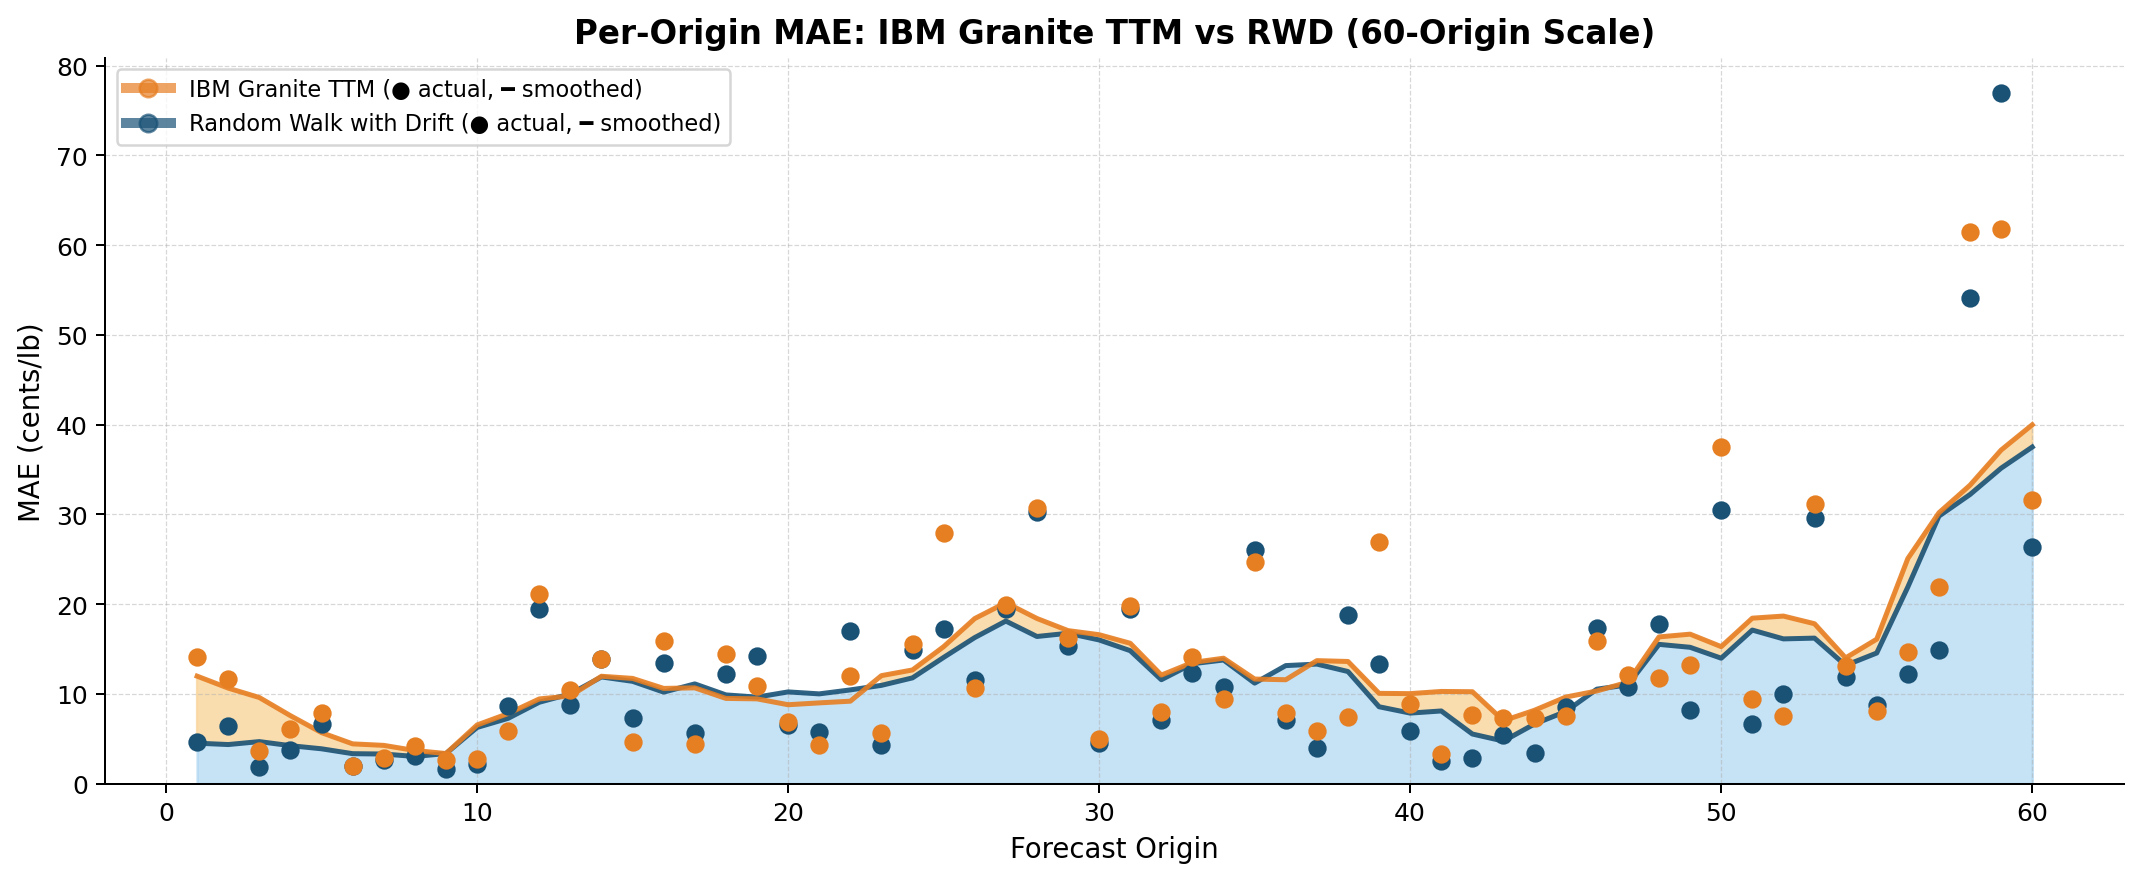


Granite beats RWD in 16 / 60 origins
Mean MAE: Granite = 13.842,  RWD = 12.789


In [45]:
from matplotlib.lines import Line2D
from scipy.ndimage import uniform_filter1d

# Per-origin MAE = mean of per-step absolute errors over the 63-day horizon.
s60 = step_errors_df[step_errors_df["scale"] == 60]
rwd_mae = (
    s60[s60["model"] == "RWD"].groupby("origin_id")["error"].mean().sort_index().values
)
gra_mae = (
    s60[s60["model"] == "Granite-TTM"]
    .groupby("origin_id")["error"]
    .mean()
    .sort_index()
    .values
)
origin_ids = np.arange(1, len(rwd_mae) + 1)

# Smoothed trend to cut through origin-to-origin noise.
W = max(5, len(rwd_mae) // 10)
smooth_r = uniform_filter1d(rwd_mae.astype(float), size=W, mode="nearest")
smooth_g = uniform_filter1d(gra_mae.astype(float), size=W, mode="nearest")

fig, ax = plt.subplots(figsize=(12, 5), dpi=180)

# Blue base layer: 0 to RWD trend (shared forecast difficulty).
ax.fill_between(origin_ids, 0, smooth_r, color="#AED6F1", alpha=0.7)
# Orange layer: only where Granite exceeds RWD (the extra error).
ax.fill_between(
    origin_ids,
    smooth_r,
    smooth_g,
    where=(smooth_g >= smooth_r),
    color="#FAD7A0",
    alpha=0.85,
)

ax.plot(origin_ids, smooth_r, color="#1A5276", linewidth=2.0, alpha=0.9)
ax.plot(origin_ids, smooth_g, color="#E67E22", linewidth=2.0, alpha=0.9)
ax.scatter(origin_ids, rwd_mae, color="#1A5276", s=40, zorder=5)
ax.scatter(origin_ids, gra_mae, color="#E67E22", s=40, zorder=5)

ax.set_title(
    "Per-Origin MAE: IBM Granite TTM vs RWD (60-Origin Scale)",
    fontsize=13,
    weight="semibold",
)
ax.set_xlabel("Forecast Origin", fontsize=11)
ax.set_ylabel("MAE (cents/lb)", fontsize=11)
ax.set_ylim(bottom=0)
ax.grid(True, ls="--", linewidth=0.5, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="#E67E22",
        markerfacecolor="#E67E22",
        markersize=7,
        linewidth=4,
        alpha=0.7,
        label="IBM Granite TTM (● actual, ━ smoothed)",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="#1A5276",
        markerfacecolor="#1A5276",
        markersize=7,
        linewidth=4,
        alpha=0.7,
        label="Random Walk with Drift (● actual, ━ smoothed)",
    ),
]
ax.legend(handles=legend_handles, loc="upper left", frameon=True, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "IBM_vs_RWD.png", dpi=300, bbox_inches="tight")
plt.show()

granite_wins = int(np.sum(gra_mae < rwd_mae))
print(f"\nGranite beats RWD in {granite_wins} / {len(rwd_mae)} origins")
print(f"Mean MAE: Granite = {gra_mae.mean():.3f},  RWD = {rwd_mae.mean():.3f}")


**Reading this plot.** Granite has lower MAE than RWD at only 16 of
60 origins. The underperformance is not driven by a few outlier
windows; the orange-shaded area (Granite's excess error above RWD) is
nearly continuous, and the smoothed curves rarely cross. Neither the
32-year pretraining corpus nor the 1,536-day context window at each
origin translate into lower point-forecast error on this series.


---

**Next notebook:** `02_backtest_stats.ipynb` &mdash; Diebold-Mariano
tests and the Model Confidence Set on the 60-origin results, to
verify that the tight MAE cluster from §10 is an actual statistical
tie rather than a ranking the sample size failed to resolve.
